Loading Dataset...

Processing Class : apple


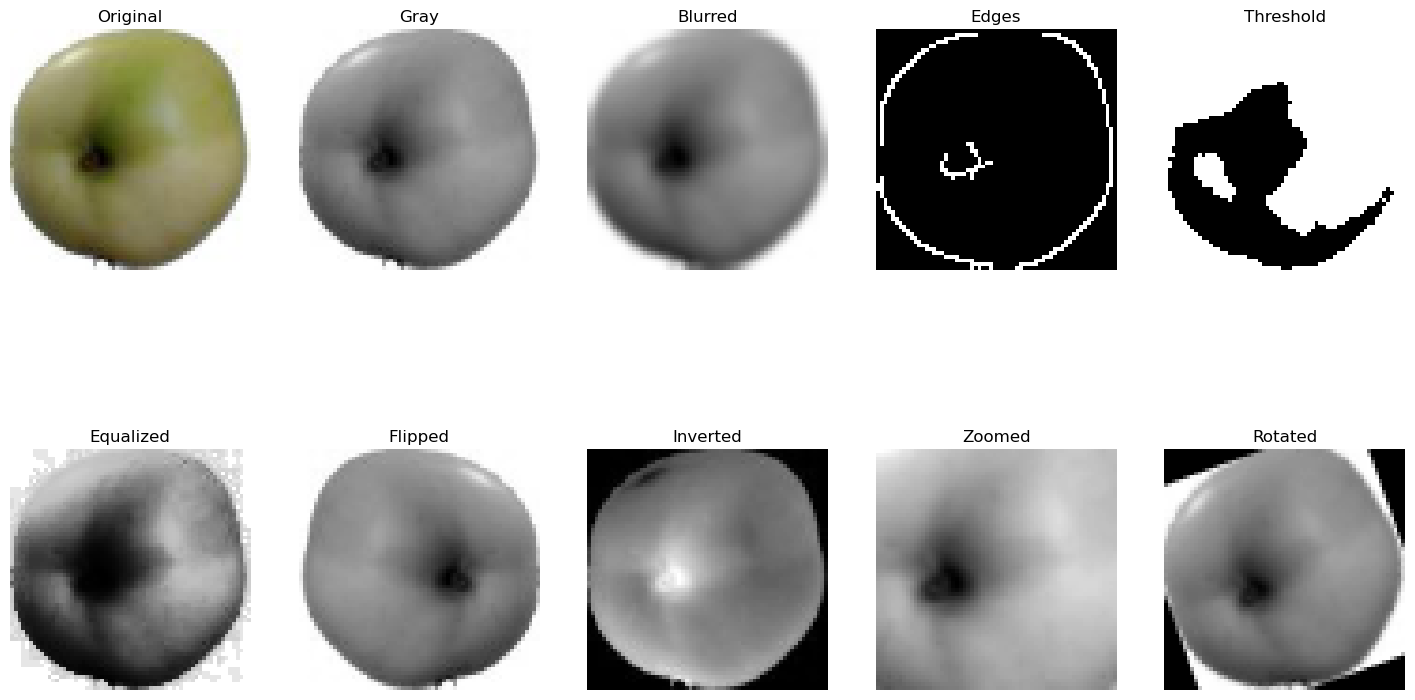

Processing Class : tomato


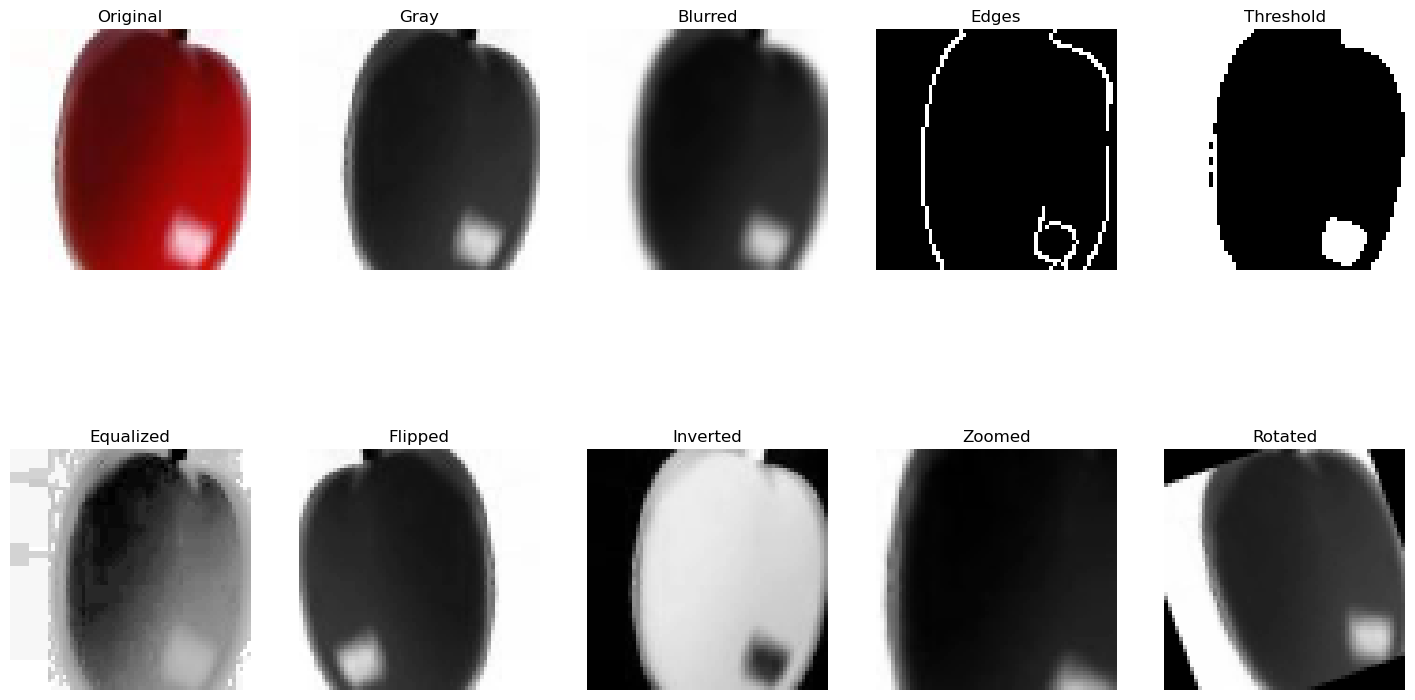


Dataset Loaded Successfully
Total Images : 14

Training Images : 11
Testing Images  : 3

MODEL : KNN

Model Training Completed

Accuracy Score :
0.6666666666666666

Confusion Matrix :
[[1 0]
 [1 1]]

Classification Report :
              precision    recall  f1-score   support

       Apple       0.50      1.00      0.67         1
      Tomato       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



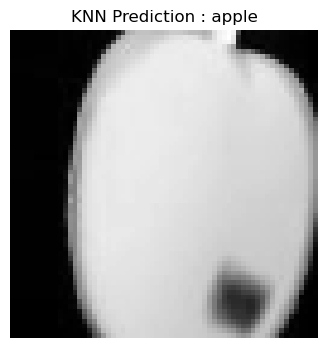


MODEL : SVM

Model Training Completed

Accuracy Score :
0.3333333333333333

Confusion Matrix :
[[1 0]
 [2 0]]

Classification Report :


/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       Apple       0.33      1.00      0.50         1
      Tomato       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



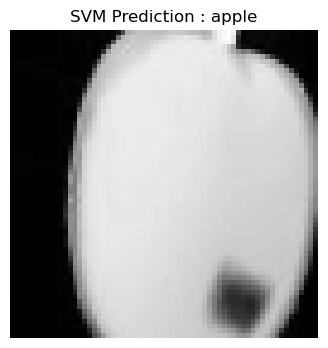


MODEL : Decision Tree

Model Training Completed

Accuracy Score :
0.6666666666666666

Confusion Matrix :
[[1 0]
 [1 1]]

Classification Report :
              precision    recall  f1-score   support

       Apple       0.50      1.00      0.67         1
      Tomato       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



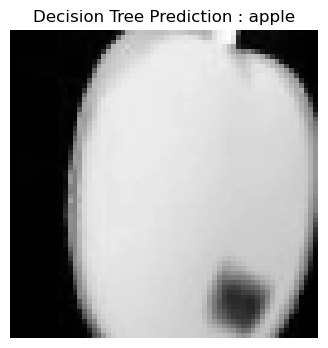


Project Completed Successfully
Preprocessing Applied :
1. Resize
2. GrayScale
3. Gaussian Blur
4. Edge Detection
5. Thresholding
6. Histogram Equalization

Data Augmentation Applied :
1. Flipping
2. Inversion
3. Zooming
4. Rotation

Models Used :
1. KNN
2. SVM
3. Decision Tree


In [1]:
# =====================================================
# COMPUTER VISION PROJECT
# IMAGE PREPROCESSING + DATA AUGMENTATION
# MULTIPLE MODEL TRAINING + EVALUATION
# =====================================================

# =====================================================
# IMPORT LIBRARIES
# =====================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# =====================================================
# CREATE EMPTY LIST
# =====================================================

data = []
labels = []

# =====================================================
# CLASS NAMES
# =====================================================

classes = ["apple", "tomato"]

print("Loading Dataset...\n")

# =====================================================
# READ DATASET
# =====================================================

for label, cls in enumerate(classes):

    folder = f"dataset/Train/{cls}"

    print("Processing Class :", cls)

    for file in os.listdir(folder):

        # Full Image Path
        path = os.path.join(folder, file)

        # Read Image
        img = cv2.imread(path)

        # Skip Broken Images
        if img is None:
            continue

        # =====================================================
        # IMAGE PREPROCESSING
        # =====================================================

        # 1. Resize Image
        resized = cv2.resize(img, (64, 64))

        # 2. Convert to Gray
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        # 3. Blur Image
        blurred = cv2.GaussianBlur(gray, (5,5), 0)

        # 4. Edge Detection
        edges = cv2.Canny(blurred, 100, 200)

        # 5. Binary Threshold
        _, threshold = cv2.threshold(
            gray,
            120,
            255,
            cv2.THRESH_BINARY
        )

        # 6. Histogram Equalization
        equalized = cv2.equalizeHist(gray)

        # =====================================================
        # DATA AUGMENTATION
        # =====================================================

        # 1. Flip Image
        flipped = cv2.flip(gray, 1)

        # 2. Invert Image
        inverted = cv2.bitwise_not(gray)

        # 3. Zoom Image
        zoom = gray[10:54, 10:54]
        zoom = cv2.resize(zoom, (64,64))

        # 4. Rotate Image
        matrix = cv2.getRotationMatrix2D((32,32), 20, 1)
        rotated = cv2.warpAffine(gray, matrix, (64,64))

        # =====================================================
        # SHOW PROCESSING RESULTS
        # =====================================================

        plt.figure(figsize=(18,10))

        # Original
        plt.subplot(2,5,1)
        plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis("off")

        # Gray
        plt.subplot(2,5,2)
        plt.imshow(gray, cmap="gray")
        plt.title("Gray")
        plt.axis("off")

        # Blurred
        plt.subplot(2,5,3)
        plt.imshow(blurred, cmap="gray")
        plt.title("Blurred")
        plt.axis("off")

        # Edge Detection
        plt.subplot(2,5,4)
        plt.imshow(edges, cmap="gray")
        plt.title("Edges")
        plt.axis("off")

        # Threshold
        plt.subplot(2,5,5)
        plt.imshow(threshold, cmap="gray")
        plt.title("Threshold")
        plt.axis("off")

        # Histogram Equalization
        plt.subplot(2,5,6)
        plt.imshow(equalized, cmap="gray")
        plt.title("Equalized")
        plt.axis("off")

        # Flipped
        plt.subplot(2,5,7)
        plt.imshow(flipped, cmap="gray")
        plt.title("Flipped")
        plt.axis("off")

        # Inverted
        plt.subplot(2,5,8)
        plt.imshow(inverted, cmap="gray")
        plt.title("Inverted")
        plt.axis("off")

        # Zoomed
        plt.subplot(2,5,9)
        plt.imshow(zoom, cmap="gray")
        plt.title("Zoomed")
        plt.axis("off")

        # Rotated
        plt.subplot(2,5,10)
        plt.imshow(rotated, cmap="gray")
        plt.title("Rotated")
        plt.axis("off")

        plt.show()

        # =====================================================
        # STORE IMAGES
        # =====================================================

        # Original Gray
        data.append(gray.flatten())
        labels.append(label)

        # Flipped
        data.append(flipped.flatten())
        labels.append(label)

        # Inverted
        data.append(inverted.flatten())
        labels.append(label)

        # Zoomed
        data.append(zoom.flatten())
        labels.append(label)

        # Rotated
        data.append(rotated.flatten())
        labels.append(label)

        # Edge Image
        data.append(edges.flatten())
        labels.append(label)

        # Threshold Image
        data.append(threshold.flatten())
        labels.append(label)

        # Use only few images for demo
        break

# =====================================================
# CONVERT INTO NUMPY ARRAY
# =====================================================

X = np.array(data)
y = np.array(labels)

print("\nDataset Loaded Successfully")
print("Total Images :", len(X))

# =====================================================
# SPLIT DATASET
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Images :", len(X_train))
print("Testing Images  :", len(X_test))

# =====================================================
# CREATE MODELS
# =====================================================

models = {

    "KNN" : KNeighborsClassifier(n_neighbors=3),

    "SVM" : SVC(),

    "Decision Tree" : DecisionTreeClassifier()

}

# =====================================================
# TRAIN AND TEST MODELS
# =====================================================

for name, model in models.items():

    print("\n===================================")
    print("MODEL :", name)
    print("===================================")

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    model.fit(X_train, y_train)

    print("\nModel Training Completed")

    # =====================================================
    # PREDICTION
    # =====================================================

    y_pred = model.predict(X_test)

    # =====================================================
    # EVALUATION
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    print("\nAccuracy Score :")
    print(accuracy)

    print("\nConfusion Matrix :")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report :")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Apple", "Tomato"]
    ))

    # =====================================================
    # SHOW PREDICTION RESULT
    # =====================================================

    plt.figure(figsize=(4,4))

    plt.imshow(X_test[0].reshape(64,64), cmap="gray")

    predicted_class = classes[y_pred[0]]

    plt.title(f"{name} Prediction : {predicted_class}")

    plt.axis("off")

    plt.show()

# =====================================================
# FINAL COMPARISON
# =====================================================

print("\nProject Completed Successfully")
print("Preprocessing Applied :")
print("1. Resize")
print("2. GrayScale")
print("3. Gaussian Blur")
print("4. Edge Detection")
print("5. Thresholding")
print("6. Histogram Equalization")

print("\nData Augmentation Applied :")
print("1. Flipping")
print("2. Inversion")
print("3. Zooming")
print("4. Rotation")

print("\nModels Used :")
print("1. KNN")
print("2. SVM")
print("3. Decision Tree")